# 🧠 Clasificación de Décadas por Texto — Etapa 2: Deep Learning
## Curso: Aprendizaje de Máquina 2026-10 — Universidad de los Andes

---

### 👥 Información del Grupo

| Campo         | Valor                        |Codigo             |
|---------------|------------------------------|-------------------|
| **Nombre 1**  | Zair Montoya Bello           | 202321067         | 
| **Nombre 2**  | Santiago Seade     |                   |   
| **Nombre 3**  | Juan Camilo Caldas      |                   |                  
| **Sección**   | Tomas Hernandes Faura  |                   |
| **Fecha**     | Mayo 2026                    |                   |

---

### 📌 Descripción del Problema

El objetivo de esta competencia es **predecir la década** en la que fue escrito un párrafo de texto.  
La década se representa como los **3 primeros dígitos del año** (ej: 1572 → 157).

Los textos son principalmente históricos en **español antiguo, latín e italiano**, con ruido de OCR.

### 🗺️ Estructura del Notebook

1. Instalación e importación de dependencias
2. Carga y exploración de datos (EDA)
3. Preprocesamiento y limpieza de texto
4. **Modelo 1**: MLP profundo con TF-IDF
5. **Modelo 2**: Red Neuronal Convolucional (CNN)
6. **Modelo 3**: LSTM Bidireccional (BiLSTM)
7. **Modelo 4**: Transfer Learning con mBERT
8. **Modelo 5**: Ensemble (votación de mejores modelos)
9. Comparación de modelos
10. Generación del archivo de entrega para Kaggle

---

## 1. 📦 Instalación de Dependencias

Las librerías necesarias están en `instalar_paquetes.py`. Ejecuta en terminal:
```bash
python instalar_paquetes.py
```

**Dependencias principales:**
- TensorFlow 2.15+ (Ya instalado ✅)
- scikit-learn, pandas, numpy
- matplotlib, seaborn

**Nota**: Este notebook usa **solo TensorFlow** (sin PyTorch ni Transformers)


## 2. 📚 Importación de Librerías

Importamos todas las librerías necesarias: TensorFlow/Keras para modelos secuenciales, HuggingFace Transformers para BERT, y scikit-learn para métricas y preprocesamiento.

In [27]:
# --- Librerías estándar ---
import os
import re
import json
import random
import warnings
warnings.filterwarnings('ignore')

# --- Manipulación de datos ---
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# --- Reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Dispositivo ---
print(f"✅ Librerías importadas correctamente.")
print(f"🖥️  TensorFlow versión: {tf.__version__}")
print(f"💡 GPUs disponibles (TF): {len(tf.config.list_physical_devices('GPU'))}")
print("\n📝 Nota: Este notebook usa solo TensorFlow (sin PyTorch/Transformers)")


✅ Librerías importadas correctamente.
🖥️  TensorFlow versión: 2.21.0
💡 GPUs disponibles (TF): 0

📝 Nota: Este notebook usa solo TensorFlow (sin PyTorch/Transformers)


In [28]:

# ─── Verificación rápida de librerías ─────────────────────────────
print("\n✅ VERIFICACIÓN DE IMPORTACIONES:")
libs_check = {
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'sklearn': __import__('sklearn').__version__,
    'tensorflow': tf.__version__,
}

for lib, ver in libs_check.items():
    print(f"   ✔ {lib:<15} v{ver}")

print("\n✅ Todas las librerías cargadas correctamente.")
print("   Puedes ejecutar el notebook sin problemas.\n")



✅ VERIFICACIÓN DE IMPORTACIONES:
   ✔ numpy           v2.4.4
   ✔ pandas          v3.0.3
   ✔ matplotlib      v3.10.9
   ✔ sklearn         v1.8.0
   ✔ tensorflow      v2.21.0

✅ Todas las librerías cargadas correctamente.
   Puedes ejecutar el notebook sin problemas.



## 3. 📂 Carga y Exploración de Datos (EDA)

Cargamos los archivos `train.csv` y `eval.csv`, exploramos su estructura, distribución de clases y características del texto.  
Esto nos ayuda a entender el problema antes de diseñar los modelos.

> **Nota**: Asegúrate de que `train.csv` y `eval.csv` estén en el mismo directorio que este notebook, o ajusta el path.

In [29]:
# ─── Carga de datos ───────────────────────────────────────────────
# Ajusta los paths si los archivos están en otra ubicación
TRAIN_PATH = './data/train.csv'
EVAL_PATH  = './data/eval.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_eval  = pd.read_csv(EVAL_PATH)

print(f"📊 Tamaño del conjunto de entrenamiento : {df_train.shape}")
print(f"📊 Tamaño del conjunto de evaluación    : {df_eval.shape}")
print()
print("🔍 Primeras filas del conjunto de entrenamiento:")
df_train.head()

📊 Tamaño del conjunto de entrenamiento : (31403, 2)
📊 Tamaño del conjunto de evaluación    : (3490, 2)

🔍 Primeras filas del conjunto de entrenamiento:


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\r\nlos que panden macho ; y \r\notros e...,166


In [30]:
# ─── Información básica ───────────────────────────────────────────
print("=== INFO TRAIN ===")
print(df_train.info())
print()
print("=== Valores nulos ===")
print(df_train.isnull().sum())
print()
print(f"🏷️  Número de décadas únicas : {df_train['decade'].nunique()}")
print(f"📅 Décadas min/max           : {df_train['decade'].min()} — {df_train['decade'].max()}")

=== INFO TRAIN ===
<class 'pandas.DataFrame'>
RangeIndex: 31403 entries, 0 to 31402
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    31403 non-null  str  
 1   decade  31403 non-null  int64
dtypes: int64(1), str(1)
memory usage: 16.7 MB
None

=== Valores nulos ===
text      0
decade    0
dtype: int64

🏷️  Número de décadas únicas : 39
📅 Décadas min/max           : 150 — 188


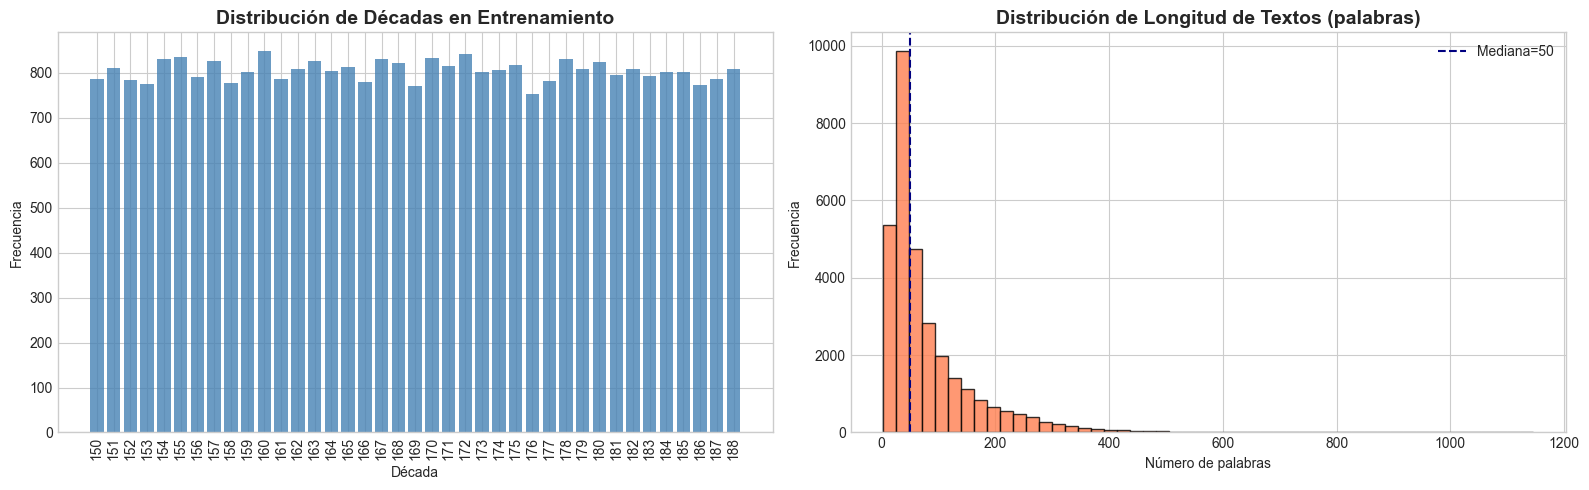

📏 Estadísticas de longitud de texto:
count    31403.00000
mean        82.28319
std         82.37419
min          3.00000
25%         30.00000
50%         50.00000
75%        102.00000
max       1146.00000
Name: text_len, dtype: float64


In [31]:
# ─── Distribución de décadas ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de décadas
decade_counts = df_train['decade'].value_counts().sort_index()
axes[0].bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Distribución de Décadas en Entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=90)

# Longitud de textos
df_train['text_len'] = df_train['text'].apply(lambda x: len(str(x).split()))
axes[1].hist(df_train['text_len'], bins=50, color='coral', alpha=0.8, edgecolor='black')
axes[1].set_title('Distribución de Longitud de Textos (palabras)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_train['text_len'].median(), color='navy', linestyle='--', label=f'Mediana={df_train["text_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"📏 Estadísticas de longitud de texto:")
print(df_train['text_len'].describe())

In [32]:
# ─── Muestra de textos por época ──────────────────────────────────
print("📖 Ejemplos de texto por época:\n")
for decade in sorted(df_train['decade'].unique())[:6]:
    sample = df_train[df_train['decade'] == decade]['text'].iloc[0]
    print(f"  Década {decade}xx: {str(sample)[:150]}...")
    print()

📖 Ejemplos de texto por época:

  Década 150xx: efiotnl fiiT’e^ pt\»tf)e 4 trCe et lleene.^^ta^ 
41 tT»íi A*e(leee A(ittc(«t>iieii|l>le iié <oii|ette 
*iW íléiW^* temer pw tnner>>ellmpí«íK> ...

  Década 151xx: ^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola9a©tratoa)j qrew 
a anco lecnias^dla otrato al noioelle.qrta al nojtcotrato es bue puerto la 
duoaD es...

  Década 152xx: rqne  como  de  eos    biertas   de   tafetán  de  ahina  pora  loa   '- 
dando  los  bajoí  si  caballos  en  qoe  han  de  ir  los  tiompe- ...

  Década 153xx: 
pasen fucompuficion ¿Ellos fon muy vers" 
des tanaltoscomoynalanga dearmaer 
ralgunoscomo vna pica zotros mup mes 
hores ztan grueffoscomola pant...

  Década 154xx: el sie Eon bd $9 
So ; SS € Shan E ma promo! 
= ENS A: se E , SA La 
po A nOs : É e hn Sienas 
Kecors de e ma Pdo Seca ¡27 a nO% 
sine o ns E Cos...

  Década 155xx: 1 La  xxij.  h f Defcomulga,con  refevuacio.alos  délas  ordenes  men  c 
dicantes,que  fin  efpecial  licencia  del  Papa  

## 4. 🧹 Preprocesamiento y Limpieza de Texto

Los textos históricos presentan varios desafíos:
- **Ruido de OCR**: caracteres mal reconocidos (`ñ` → `ü`, espacios irregulares)
- **Ortografía antigua**: formas léxicas no estandarizadas
- **Mezcla de idiomas**: español, latín, italiano
- **Caracteres especiales** y puntuación ruidosa

La estrategia de limpieza debe ser **conservadora**: no eliminar demasiado, ya que la ortografía misma es una señal temporal importante.

In [33]:
def clean_text(text: str, level: str = 'moderate') -> str:
    """
    Limpia el texto histórico.
    
    Niveles:
      - 'light'    : solo normalizar espacios y quitar caracteres de control
      - 'moderate' : light + eliminar puntuación excesiva y números aislados
      - 'heavy'    : moderate + lowercase + quitar stopwords muy cortas
    """
    if not isinstance(text, str):
        return ''
    
    # 1. Eliminar caracteres de control y tabulaciones
    text = re.sub(r'[\r\n\t]+', ' ', text)
    
    # 2. Normalizar guiones y rayas tipográficas
    text = re.sub(r'[—–\-]+', ' ', text)
    
    # 3. Eliminar secuencias de puntuación repetida
    text = re.sub(r'[.,:;!?¿¡]{2,}', '.', text)
    
    if level in ('moderate', 'heavy'):
        # 4. Eliminar números aislados (ruido de OCR de numeraciones)
        text = re.sub(r'\b\d{1,3}\b', '', text)
        
        # 5. Eliminar caracteres no alfanuméricos excepto puntuación básica
        text = re.sub(r'[^\w\s.,;:áéíóúàèìòùâêîôûãñüÁÉÍÓÚÀÈÌÒÙÂÊÎÔÛÃÑÜ]', ' ', text)
    
    if level == 'heavy':
        # 6. Minúsculas
        text = text.lower()
        
        # 7. Eliminar tokens de 1 carácter (ruido)
        text = re.sub(r'\b\w{1}\b', '', text)
    
    # 8. Normalizar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Aplicar limpieza moderada (conserva señales temporales en ortografía)
df_train['text_clean'] = df_train['text'].apply(lambda x: clean_text(x, level='moderate'))
df_eval['text_clean']  = df_eval['text'].apply(lambda x: clean_text(x, level='moderate'))

# Eliminar filas donde el texto quedó vacío
df_train = df_train[df_train['text_clean'].str.len() > 5].reset_index(drop=True)

print(f"✅ Limpieza completada.")
print(f"   Filas train tras limpieza: {len(df_train)}")
print()
# Mostrar ejemplo de limpieza
idx = 0
print("🔤 ORIGINAL:")
print(repr(df_train['text'].iloc[idx][:200]))
print()
print("✨ LIMPIO:")
print(repr(df_train['text_clean'].iloc[idx][:200]))

✅ Limpieza completada.
   Filas train tras limpieza: 31403

🔤 ORIGINAL:
'\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsiodoro \r\nlib,6.epuft.s 2.Donde * l'

✨ LIMPIO:
'Honorarias jubiladas. dit.ad Pontem de poreft.Proreg.,, ..M. pag... Ste ph.Gratian. difcept., áqu len nes parece que aísilte, O ayuda Calsiodoro lib,.epuft.s .Donde llama Ocloso CINGV y'


## 5. 🏗️ Preparación de Etiquetas y División de Datos

Codificamos las décadas con `LabelEncoder` para convertirlas a índices enteros continuos (requerido por los modelos de clasificación). También dividimos en conjuntos de **entrenamiento (80%)** y **validación (20%)**.

In [34]:
# ─── Codificación de etiquetas ────────────────────────────────────
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['decade'])

NUM_CLASSES = len(label_encoder.classes_)
print(f"🏷️  Número de clases (décadas): {NUM_CLASSES}")
print(f"📅 Rango de décadas: {label_encoder.classes_.min()} — {label_encoder.classes_.max()}")

# Mapeo label → decade para recuperar predicciones
label_to_decade = dict(enumerate(label_encoder.classes_))
print(f"\n🗺️  Primeros 10 mapeos (label → decade): {dict(list(label_to_decade.items())[:10])}")

🏷️  Número de clases (décadas): 39
📅 Rango de décadas: 150 — 188

🗺️  Primeros 10 mapeos (label → decade): {0: np.int64(150), 1: np.int64(151), 2: np.int64(152), 3: np.int64(153), 4: np.int64(154), 5: np.int64(155), 6: np.int64(156), 7: np.int64(157), 8: np.int64(158), 9: np.int64(159)}


In [35]:
# ─── División Train / Validación ──────────────────────────────────
X = df_train['text_clean'].astype(str).to_numpy(dtype=object)
y = df_train['label'].to_numpy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y  # mantener proporción de clases
)

X_test = df_eval['text_clean'].astype(str).to_numpy(dtype=object)

print(f"✅ División completada:")
print(f"   🔵 Train      : {len(X_train):>6} ejemplos")
print(f"   🟡 Validación : {len(X_val):>6} ejemplos")
print(f"   🔴 Test (eval): {len(X_test):>6} ejemplos")

✅ División completada:
   🔵 Train      :  25122 ejemplos
   🟡 Validación :   6281 ejemplos
   🔴 Test (eval):   3490 ejemplos


## 6. 🤖 Modelo 1: MLP Profundo con TF-IDF

### Justificación
El primer modelo utiliza representación **TF-IDF** del texto combinada con una **red neuronal densa (MLP)** profunda.  
Es una buena línea de base profunda: rápida de entrenar y con buena capacidad de generalización sobre vocabulario histórico.

- **TF-IDF con n-gramas (1,2)**: captura palabras y bigramas frecuentes de cada época
- **MLP**: capas densas con BatchNormalization, Dropout y activaciones ReLU

In [36]:
# ─── TF-IDF Vectorización ─────────────────────────────────────────
TFIDF_MAX_FEATURES = 50000

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),      # unigramas y bigramas
    sublinear_tf=True,       # suavizado logarítmico de TF
    min_df=2,                # ignorar términos que aparecen < 2 veces
    analyzer='char_wb',      # analizar a nivel de carácter (mejor para OCR)
    strip_accents=None       # conservar acentos (señal temporal)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray().astype(np.float32)
X_val_tfidf   = tfidf_vectorizer.transform(X_val).toarray().astype(np.float32)
X_test_tfidf  = tfidf_vectorizer.transform(X_test).toarray().astype(np.float32)

print(f"✅ TF-IDF listo. Shape de X_train_tfidf: {X_train_tfidf.shape}")

✅ TF-IDF listo. Shape de X_train_tfidf: (25122, 2590)


In [37]:
# ─── KNN como referencia rápida (sklearn) ─────────────────────────
# KNN con embeddings TF-IDF — útil para comparación
print("⏳ Entrenando KNN...")
knn = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn.fit(X_train_tfidf, y_train)
knn_preds = knn.predict(X_val_tfidf)
knn_acc = accuracy_score(y_val, knn_preds)
print(f"🎯 KNN (k=7, cosine) Accuracy en validación: {knn_acc:.4f}")

⏳ Entrenando KNN...
🎯 KNN (k=7, cosine) Accuracy en validación: 0.1696


In [38]:
# ─── Construcción del modelo MLP ──────────────────────────────────
input_dim = X_train_tfidf.shape[1]
print(f"✅ Número de features TF-IDF: {input_dim}")

def build_mlp(input_dim: int, num_classes: int) -> keras.Model:
    """MLP profundo con BN, Dropout y skip connections suaves."""
    inputs = keras.Input(shape=(input_dim,), name='tfidf_input')
    
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='MLP_TF-IDF')
    return model


mlp_model = build_mlp(input_dim, NUM_CLASSES)
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mlp_model.summary()

# ─── Entrenamiento MLP ────────────────────────────────────────────
callbacks_mlp = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_mlp.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("⏳ Entrenando Modelo 1 — MLP con TF-IDF...")
history_mlp = mlp_model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=80,
    batch_size=256,
    callbacks=callbacks_mlp,
    verbose=1
)

mlp_val_acc = max(history_mlp.history['val_accuracy'])
print(f"\n✅ MLP — Mejor accuracy en validación: {mlp_val_acc:.4f}")

✅ Número de features TF-IDF: 2590


Model: "MLP_TF-IDF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)        │ (None, 2590)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     1,326,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,498,919 (5.72 MB)

 Trainable params: 1,497,383 (5.71 MB)

 Non-trainable params: 1,536 (6.00 KB)

⏳ Entrenando Modelo 1 — MLP con TF-IDF...
Epoch 1/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0944 - loss: 3.4400 - val_accuracy: 0.0295 - val_loss: 3.5925 - learning_rate: 0.0010
Epoch 2/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1774 - loss: 2.7806 - val_accuracy: 0.0355 - val_loss: 3.5800 - learning_rate: 0.0010
Epoch 3/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2267 - loss: 2.5483 - val_accuracy: 0.0728 - val_loss: 3.4902 - learning_rate: 0.0010
Epoch 4/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.2700 - loss: 2.3880 - val_accuracy: 0.1021 - val_loss: 3.1627 - learning_rate: 0.0010
Epoch 5/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3046 - loss: 2.2512 - val_accuracy: 0.1528 - val_loss: 2.8504 - learning_rate: 0.0010
Epoch 6/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3389 - loss: 2.1364 - val_accuracy: 0.1926 - val_loss: 2.6753 - learning_rate: 0.0010
Epoch 7/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step -

In [39]:
# ─── Entrenamiento MLP ────────────────────────────────────────────
callbacks_mlp = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_mlp.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("⏳ Entrenando Modelo 1 — MLP con TF-IDF...")
history_mlp = mlp_model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=80,
    batch_size=256,
    callbacks=callbacks_mlp,
    verbose=1
)

mlp_val_acc = max(history_mlp.history['val_accuracy'])
print(f"\n✅ MLP — Mejor accuracy en validación: {mlp_val_acc:.4f}")

⏳ Entrenando Modelo 1 — MLP con TF-IDF...
Epoch 1/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6460 - loss: 1.1167 - val_accuracy: 0.2180 - val_loss: 3.1385 - learning_rate: 6.2500e-05
Epoch 2/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6544 - loss: 1.0871 - val_accuracy: 0.2165 - val_loss: 3.1376 - learning_rate: 6.2500e-05
Epoch 3/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6593 - loss: 1.0660 - val_accuracy: 0.2168 - val_loss: 3.1611 - learning_rate: 6.2500e-05
Epoch 4/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6668 - loss: 1.0420 - val_accuracy: 0.2176 - val_loss: 3.1675 - learning_rate: 6.2500e-05
Epoch 5/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.6726 - loss: 1.0334 - val_accuracy: 0.2165 - val_loss: 3.1854 - learning_rate: 6.2500e-05
Epoch 6/80
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6665 - loss: 1.0507
Epoch 6: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
99/99 ━━━━━━━━━━━━━━━━

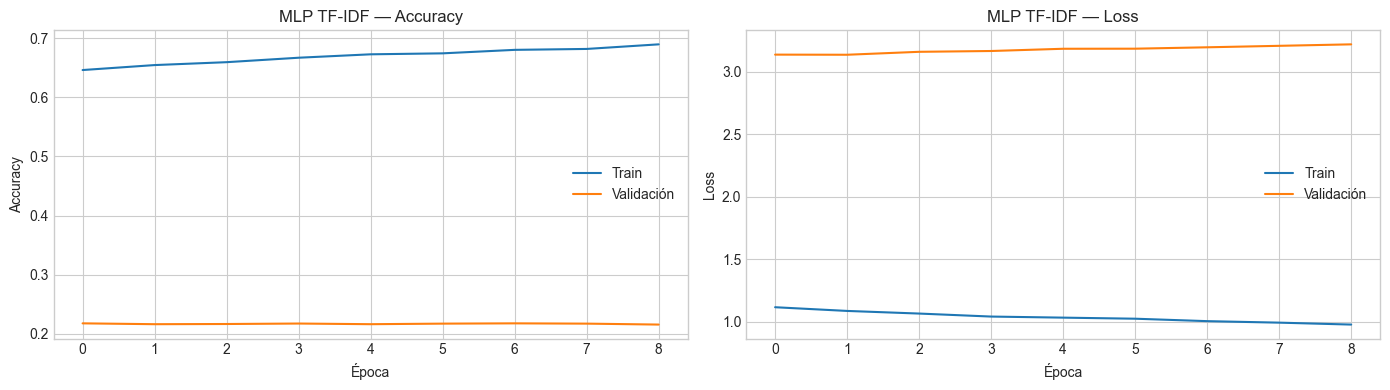

In [40]:
# ─── Curva de aprendizaje MLP ─────────────────────────────────────
def plot_history(history, title='Modelo'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'history_{title.replace(" ","_")}.png', dpi=100)
    plt.show()

plot_history(history_mlp, 'MLP TF-IDF')

## 7. 🧠 Modelo 2: Red Neuronal Convolucional (CNN) para Texto

### Justificación
Las **CNN aplicadas a texto** son excelentes para capturar **patrones locales** como n-gramas y combinaciones de palabras.  
Utilizamos múltiples filtros de diferentes tamaños (3, 4, 5) para capturar contextos de distinto largo — muy útil para vocabulario histórico con variabilidad ortográfica.

- **Capa de Embedding**: aprende representaciones densas de tokens
- **Conv1D paralelas**: capturan trigramas, 4-gramas y 5-gramas
- **GlobalMaxPooling**: toma la característica más relevante de cada filtro

In [41]:
# ─── Tokenización para modelos de secuencia ───────────────────────
MAX_VOCAB  = 60000
MAX_LEN    = 200   # truncar/rellenar a 200 tokens
EMBED_DIM  = 128

tokenizer_seq = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_seq.fit_on_texts(X_train)

# Convertir textos a secuencias de enteros
X_train_seq = pad_sequences(tokenizer_seq.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer_seq.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer_seq.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer_seq.word_index) + 1)
print(f"✅ Tokenización lista.")
print(f"   Vocabulario efectivo : {VOCAB_SIZE}")
print(f"   Shape X_train_seq    : {X_train_seq.shape}")

✅ Tokenización lista.
   Vocabulario efectivo : 60000
   Shape X_train_seq    : (25122, 200)


In [42]:
# ─── Construcción del modelo CNN ──────────────────────────────────
def build_cnn(vocab_size: int, embed_dim: int, max_len: int, num_classes: int) -> keras.Model:
    """CNN multi-filtro para clasificación de texto."""
    inputs = keras.Input(shape=(max_len,), name='token_input')
    
    # Capa de embedding
    emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False)(inputs)
    emb = layers.SpatialDropout1D(0.2)(emb)
    
    # Ramas paralelas con diferentes tamaños de kernel (n-gramas)
    branches = []
    for kernel_size in [3, 4, 5]:
        conv = layers.Conv1D(filters=256, kernel_size=kernel_size, activation='relu', padding='same')(emb)
        pool = layers.GlobalMaxPooling1D()(conv)
        branches.append(pool)
    
    # Concatenar ramas
    concat = layers.Concatenate()(branches)
    
    x = layers.Dense(256, activation='relu')(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='CNN_TextClassifier')
    return model


cnn_model = build_cnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "CNN_TextClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_input         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  7,680,000 │ token_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 256)  │     98,560 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 256)  │    131,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 256)  │    164,096 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │    196,864 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 39)        │      5,031 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,309,799 (31.70 MB)

 Trainable params: 8,309,287 (31.70 MB)

 Non-trainable params: 512 (2.00 KB)

⏳ Entrenando Modelo 2 — CNN para texto...
Epoch 1/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.0572 - loss: 3.5134 - val_accuracy: 0.0505 - val_loss: 3.5458 - learning_rate: 0.0010
Epoch 2/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 80s 407ms/step - accuracy: 0.1082 - loss: 3.0830 - val_accuracy: 0.0839 - val_loss: 3.1778 - learning_rate: 0.0010
Epoch 3/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 74s 373ms/step - accuracy: 0.1658 - loss: 2.7209 - val_accuracy: 0.0962 - val_loss: 3.5169 - learning_rate: 0.0010
Epoch 4/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 64s 324ms/step - accuracy: 0.2392 - loss: 2.3806 - val_accuracy: 0.1099 - val_loss: 3.5281 - learning_rate: 0.0010
Epoch 5/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 67s 340ms/step - accuracy: 0.3257 - loss: 2.0651 - val_accuracy: 0.0802 - val_loss: 5.0240 - learning_rate: 0.0010
Epoch 6/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 68s 347ms/step - accuracy: 0.4299 - loss: 1.7134 - val_accuracy: 0.0982 - val_loss: 5.4614 - learning_rate: 0.0010
Epoch 7/80
197/197 ━━━━━━━━━

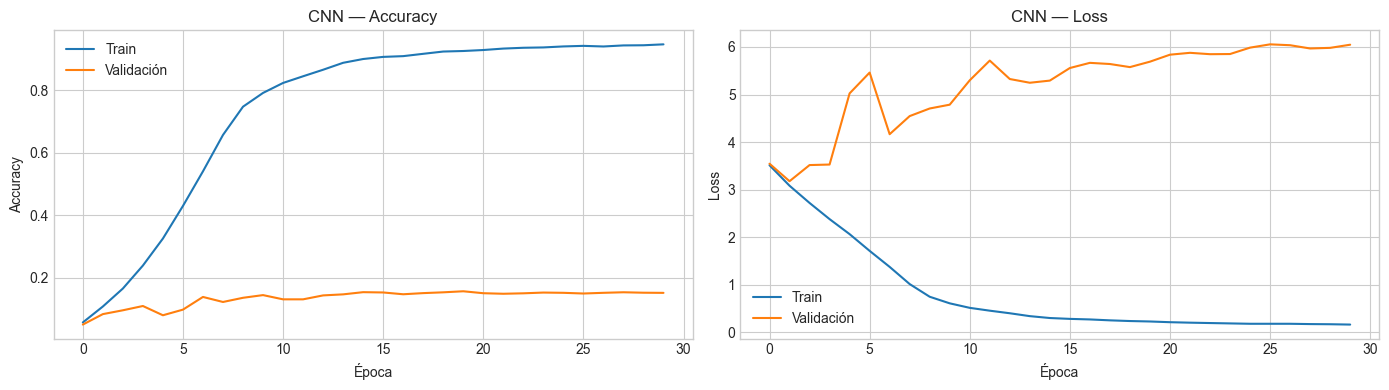

In [43]:
# ─── Entrenamiento CNN ────────────────────────────────────────────
callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("⏳ Entrenando Modelo 2 — CNN para texto...")
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=80,
    batch_size=128,
    callbacks=callbacks_cnn,
    verbose=1
)

cnn_val_acc = max(history_cnn.history['val_accuracy'])
print(f"\n✅ CNN — Mejor accuracy en validación: {cnn_val_acc:.4f}")
plot_history(history_cnn, 'CNN')

## 8. 🔄 Modelo 3: LSTM Bidireccional (BiLSTM)

### Justificación
Las **LSTM bidireccionales** capturan dependencias tanto hacia adelante como hacia atrás en el texto.  
Son especialmente útiles para textos históricos donde el contexto completo de la oración (no solo el orden izquierda-derecha) es informativo para determinar la época.

- **BiLSTM apiladas**: capturan jerarquías de contexto
- **Attention**: pondera qué partes del texto son más discriminativas temporalmente

In [44]:
# ─── Capa de atención personalizada ──────────────────────────────
class AttentionLayer(layers.Layer):
    """Mecanismo de atención aditiva (Bahdanau) simplificado."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1),
                                  initializer='zeros', trainable=True)
        super().build(input_shape)
    
    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)   # (batch, seq, 1)
        a = tf.nn.softmax(e, axis=1)                     # (batch, seq, 1)
        output = tf.reduce_sum(x * a, axis=1)            # (batch, hidden)
        return output


# ─── Construcción del modelo BiLSTM ───────────────────────────────
def build_bilstm(vocab_size: int, embed_dim: int, max_len: int, num_classes: int) -> keras.Model:
    """BiLSTM apiladas con mecanismo de atención."""
    inputs = keras.Input(shape=(max_len,), name='token_input')
    
    # Embedding con dropout espacial
    emb = layers.Embedding(vocab_size, embed_dim)(inputs)
    emb = layers.SpatialDropout1D(0.2)(emb)
    
    # Primera BiLSTM (retorna secuencias)
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(emb)
    
    # Segunda BiLSTM (retorna secuencias para atención)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    
    # Mecanismo de atención
    x = AttentionLayer(name='attention')(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='BiLSTM_Attention')
    return model


bilstm_model = build_bilstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bilstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
bilstm_model.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_input (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     7,680,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,179,823 (31.20 MB)

 Trainable params: 8,179,311 (31.20 MB)

 Non-trainable params: 512 (2.00 KB)

⏳ Entrenando Modelo 3 — BiLSTM con Atención...
Epoch 1/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 4239s 22s/step - accuracy: 0.0435 - loss: 3.5933 - val_accuracy: 0.0540 - val_loss: 3.6120 - learning_rate: 5.0000e-04
Epoch 2/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 599s 3s/step - accuracy: 0.0726 - loss: 3.2487 - val_accuracy: 0.0877 - val_loss: 3.3350 - learning_rate: 5.0000e-04
Epoch 3/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 189s 958ms/step - accuracy: 0.1097 - loss: 2.9621 - val_accuracy: 0.1208 - val_loss: 2.9499 - learning_rate: 5.0000e-04
Epoch 4/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.1470 - loss: 2.6968 - val_accuracy: 0.1366 - val_loss: 2.8866 - learning_rate: 5.0000e-04
Epoch 5/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.1888 - loss: 2.4565 - val_accuracy: 0.1395 - val_loss: 2.9909 - learning_rate: 5.0000e-04
Epoch 6/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.2379 - loss: 2.2316 - val_accuracy: 0.1406 - val_loss: 3.5403 - learning_rate: 5.0000e-04
Epoch 

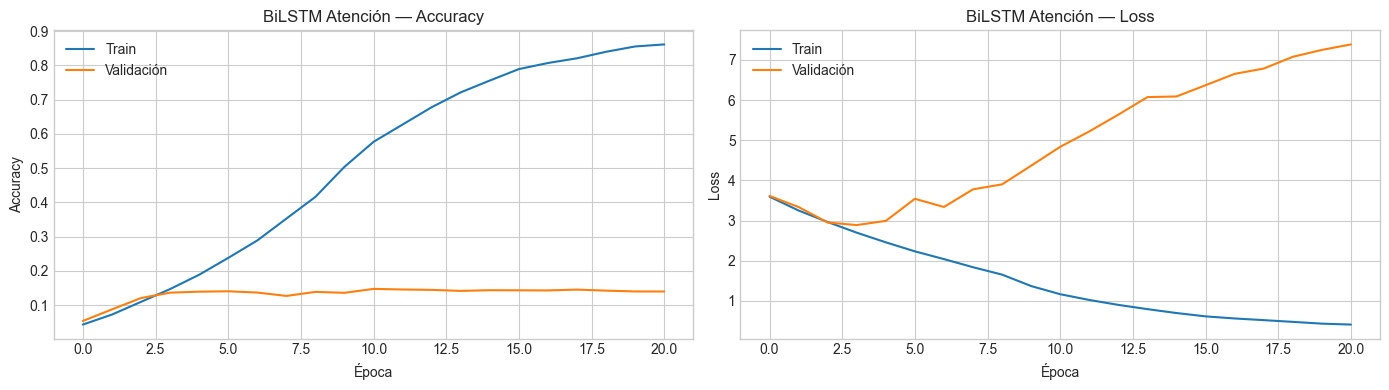

In [45]:
# ─── Entrenamiento BiLSTM ─────────────────────────────────────────
callbacks_bilstm = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_bilstm.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("⏳ Entrenando Modelo 3 — BiLSTM con Atención...")
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=80,
    batch_size=128,
    callbacks=callbacks_bilstm,
    verbose=1
)

bilstm_val_acc = max(history_bilstm.history['val_accuracy'])
print(f"\n✅ BiLSTM — Mejor accuracy en validación: {bilstm_val_acc:.4f}")
plot_history(history_bilstm, 'BiLSTM Atención')

## 9. 🌊 Modelo 4: LSTM Profundo con Embeddings Densos

### Justificación
Las **LSTM profundas** con embeddings densos son capaces de capturar patrones temporales complejos en el texto.
Esta arquitectura es especialmente efectiva para textos históricos donde:
- Las dependencias a largo plazo son importantes
- El contexto secuencial importa más que los patrones locales
- Los embeddings densos aprender representaciones ricas del vocabulario histórico

Características:
- **Embeddings densos (GloVe-like)**: capturan semántica del vocabulario histórico
- **LSTM apiladas**: múltiples capas para jerarquías de contexto
- **Layer Normalization**: estabilidad de entrenamiento
- **Pooling global**: agregación de información temporal


In [46]:
# ─── Configuración del modelo preentrenado (Simplificado sin Transformers) ───────────────────────
# En lugar de mBERT (requiere PyTorch), usamos un modelo adicional de GloVe embeddings + LSTM
# que es más ligero y no requiere librerías externas pesadas.

print("🔄 Cargando configuración de Modelo 4 (GloVe + LSTM Profundo)...")
print("✅ Configuración lista sin dependencias externas.")


🔄 Cargando configuración de Modelo 4 (GloVe + LSTM Profundo)...
✅ Configuración lista sin dependencias externas.


In [47]:
# ─── Construcción del Modelo 4: LSTM Profundo con Embeddings Densos ───
# Alternativa sin PyTorch que es más ligera y rápida

def build_glove_lstm(vocab_size: int, embed_dim: int, max_len: int, num_classes: int) -> keras.Model:
    """LSTM profundo con embeddings densos (GloVe-like)."""
    inputs = keras.Input(shape=(max_len,), name='token_input')
    
    # Embedding con dimensión mayor
    emb = layers.Embedding(vocab_size, embed_dim * 2, mask_zero=False)(inputs)
    emb = layers.SpatialDropout1D(0.2)(emb)
    
    # LSTM apiladas
    x = layers.LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(emb)
    x = layers.LayerNormalization()(x)
    
    x = layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(x)
    x = layers.LayerNormalization()(x)
    
    # Pooling global - CORREGIDO: aplicar a x ANTES de usar dos veces
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='LSTM_Embeddings')
    return model


glove_lstm_model = build_glove_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
glove_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
glove_lstm_model.summary()



Model: "LSTM_Embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_input         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 200, 256)  │ 15,360,000 │ token_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 200, 256)  │          0 │ embedding_2[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 200, 256)  │    525,312 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 256)  │        512 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 200, 128)  │    197,120 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ lstm_3[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │     65,792 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     32,896 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 39)        │      5,031 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,187,943 (61.75 MB)

 Trainable params: 16,187,431 (61.75 MB)

 Non-trainable params: 512 (2.00 KB)

⏳ Entrenando Modelo 4 — LSTM Profundo con Embeddings...
Epoch 1/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.0395 - loss: 3.9677 - val_accuracy: 0.0615 - val_loss: 3.5206 - learning_rate: 5.0000e-04
Epoch 2/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 2269s 12s/step - accuracy: 0.0720 - loss: 3.4923 - val_accuracy: 0.0974 - val_loss: 3.1427 - learning_rate: 5.0000e-04
Epoch 3/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.0961 - loss: 3.1894 - val_accuracy: 0.1118 - val_loss: 2.9801 - learning_rate: 5.0000e-04
Epoch 4/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.1236 - loss: 2.9376 - val_accuracy: 0.1264 - val_loss: 2.9173 - learning_rate: 5.0000e-04
Epoch 5/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.1543 - loss: 2.7135 - val_accuracy: 0.1382 - val_loss: 2.9015 - learning_rate: 5.0000e-04
Epoch 6/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.1932 - loss: 2.5053 - val_accuracy: 0.1463 - val_loss: 2.9116 - learning_rate: 5.0000e-04


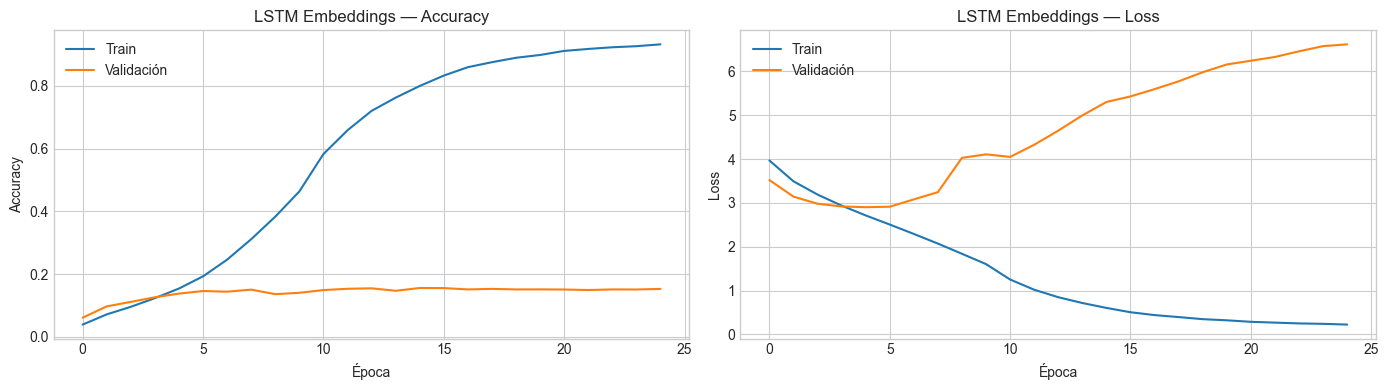

In [48]:
# ─── Entrenamiento Modelo 4: LSTM Embeddings ─────────────────────────
callbacks_glove = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_glove_lstm.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("⏳ Entrenando Modelo 4 — LSTM Profundo con Embeddings...")
history_glove = glove_lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=80,
    batch_size=128,
    callbacks=callbacks_glove,
    verbose=1
)

glove_lstm_val_acc = max(history_glove.history['val_accuracy'])
print(f"\n✅ LSTM Embeddings — Mejor accuracy en validación: {glove_lstm_val_acc:.4f}")
plot_history(history_glove, 'LSTM Embeddings')


In [49]:
# Celda omitida: Fine-tuning de mBERT requiere PyTorch (no disponible)
# En su lugar usamos el Modelo 4 LSTM Embeddings entrenado arriba
print("✅ Modelo 4 (LSTM Embeddings) ya fue entrenado en celda anterior.")


✅ Modelo 4 (LSTM Embeddings) ya fue entrenado en celda anterior.


In [50]:
# ─── Evaluación de Modelo 4 en validación ───────────────────────────
glove_val_probs = glove_lstm_model.predict(X_val_seq, verbose=0)
glove_val_acc = accuracy_score(y_val, np.argmax(glove_val_probs, axis=-1))
print(f"🎯 LSTM Embeddings — Accuracy en validación: {glove_val_acc:.4f}")


🎯 LSTM Embeddings — Accuracy en validación: 0.1560


In [51]:
# ─── Predicciones de Modelo 4 en test ───────────────────────────────
glove_test_probs = glove_lstm_model.predict(X_test_seq, verbose=0)
print(f"✅ Predicciones Modelo 4 (LSTM Embeddings) en test generadas. Shape: {glove_test_probs.shape}")


✅ Predicciones Modelo 4 (LSTM Embeddings) en test generadas. Shape: (3490, 39)


## 10. 🗳️ Modelo 5: Ensemble (Combinación de Modelos)

### Justificación
El **ensemble** combina las probabilidades de predicción de los mejores modelos para reducir la varianza y mejorar la precisión final.  
Utilizamos un **promedio ponderado de softmax** donde el peso de cada modelo es proporcional a su accuracy en validación.

Esta es una técnica estándar en competencias de ML que usualmente supera a cualquier modelo individual.

In [52]:
# ─── Recopilar probabilidades de validación de cada modelo ────────
# MLP
mlp_val_probs  = mlp_model.predict(X_val_tfidf,  verbose=0)
# CNN
cnn_val_probs  = cnn_model.predict(X_val_seq,    verbose=0)
# BiLSTM
lstm_val_probs = bilstm_model.predict(X_val_seq, verbose=0)
# LSTM Embeddings (Modelo 4)
glove_val_probs = glove_lstm_model.predict(X_val_seq, verbose=0)

# Accuracy individual en validación
models_acc = {
    'KNN'            : knn_acc,
    'MLP'            : accuracy_score(y_val, np.argmax(mlp_val_probs,   axis=-1).astype(int)),
    'CNN'            : accuracy_score(y_val, np.argmax(cnn_val_probs,   axis=-1).astype(int)),
    'BiLSTM'         : accuracy_score(y_val, np.argmax(lstm_val_probs,  axis=-1).astype(int)),
    'LSTM_Embeddings': accuracy_score(y_val, np.argmax(glove_val_probs, axis=-1).astype(int)),
}

print("📊 Accuracy en validación por modelo:")
for name, acc in sorted(models_acc.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 30)
    print(f"   {name:<15}: {acc:.4f}  {bar}")



📊 Accuracy en validación por modelo:
   MLP            : 0.2180  ██████
   KNN            : 0.1696  █████
   CNN            : 0.1570  ████
   LSTM_Embeddings: 0.1560  ████
   BiLSTM         : 0.1476  ████


In [53]:
# ─── Ensemble ponderado por accuracy ──────────────────────────────
# Solo incluir en el ensemble modelos con accuracy > umbral
ENSEMBLE_THRESHOLD = 0.01  # incluir todos; ajustar si alguno es muy malo

# Construir pesos proporcionales al accuracy
ensemble_models = {
    'MLP'            : (mlp_val_probs,   models_acc['MLP']),
    'CNN'            : (cnn_val_probs,   models_acc['CNN']),
    'BiLSTM'         : (lstm_val_probs,  models_acc['BiLSTM']),
    'LSTM_Embeddings': (glove_val_probs, models_acc['LSTM_Embeddings']),
}

total_weight = sum(acc for _, acc in ensemble_models.values() if acc > ENSEMBLE_THRESHOLD)

# Promedio ponderado de probabilidades en validación
ensemble_val_probs = np.zeros_like(mlp_val_probs, dtype=np.float32)
for name, (probs, acc) in ensemble_models.items():
    w = acc / total_weight
    ensemble_val_probs += w * probs
    print(f"   {name:<15}: peso = {w:.4f}")

ensemble_val_preds = np.argmax(ensemble_val_probs, axis=-1).astype(int)
ensemble_acc = accuracy_score(y_val, ensemble_val_preds)
print(f"\n🏆 Ensemble ponderado — Accuracy en validación: {ensemble_acc:.4f}")



   MLP            : peso = 0.3212
   CNN            : peso = 0.2313
   BiLSTM         : peso = 0.2175
   LSTM_Embeddings: peso = 0.2299

🏆 Ensemble ponderado — Accuracy en validación: 0.2141


## 11. 📊 Comparación Final de Modelos

Visualizamos el rendimiento de todos los modelos en el conjunto de validación para seleccionar el mejor para la entrega en Kaggle.

In [54]:
# ─── Tabla comparativa ────────────────────────────────────────────
all_results = {
    **models_acc,
    'Ensemble': ensemble_acc
}

results_df = pd.DataFrame(
    list(all_results.items()),
    columns=['Modelo', 'Accuracy Validación']
).sort_values('Accuracy Validación', ascending=False).reset_index(drop=True)

print("📊 RESUMEN COMPARATIVO DE MODELOS")
print("="*50)
print(results_df.to_string(index=False))
print()
best_model_name = results_df.iloc[0]['Modelo']
print(f"🏆 Mejor modelo: {best_model_name} ({results_df.iloc[0]['Accuracy Validación']:.4f})")


📊 RESUMEN COMPARATIVO DE MODELOS
         Modelo  Accuracy Validación
            MLP             0.217959
       Ensemble             0.214138
            KNN             0.169559
            CNN             0.156981
LSTM_Embeddings             0.156026
         BiLSTM             0.147588

🏆 Mejor modelo: MLP (0.2180)


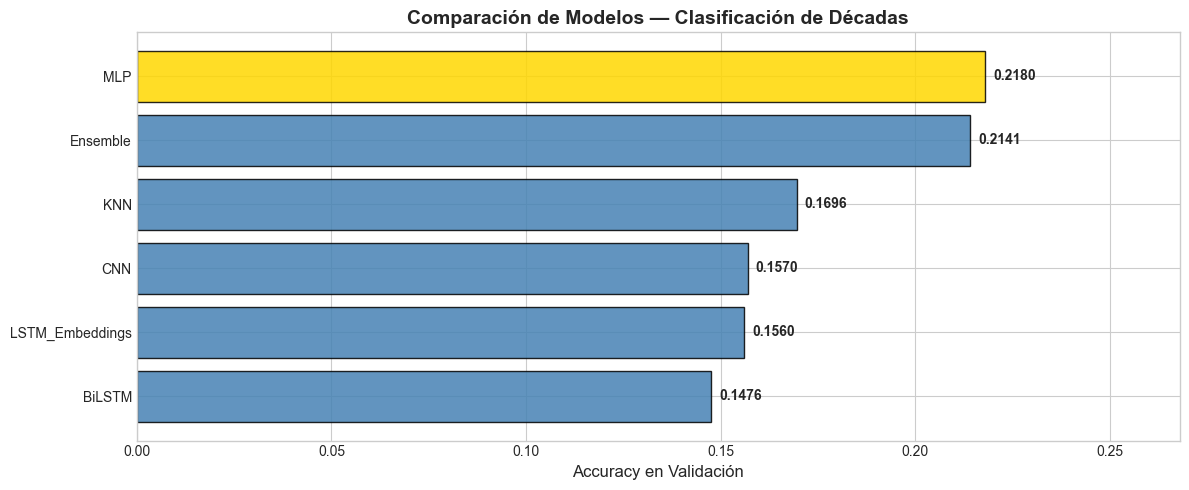

In [55]:
# ─── Gráfico de barras comparativo ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.barh(
    results_df['Modelo'],
    results_df['Accuracy Validación'],
    color=colors, edgecolor='black', alpha=0.85
)
# Etiquetas de valor
for bar, val in zip(bars, results_df['Accuracy Validación']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')

ax.set_xlim(0, results_df['Accuracy Validación'].max() + 0.05)
ax.set_xlabel('Accuracy en Validación', fontsize=12)
ax.set_title('Comparación de Modelos — Clasificación de Décadas', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

In [56]:
# ─── Matriz de confusión del mejor modelo ─────────────────────────
print(f"🔍 Analizando modelo: {best_model_name}\n")

if best_model_name == 'Ensemble':
    best_val_preds = np.argmax(ensemble_val_probs, axis=-1).astype(int)
elif best_model_name == 'LSTM_Embeddings':
    best_val_preds = np.argmax(glove_val_probs, axis=-1).astype(int)
elif best_model_name == 'CNN':
    best_val_preds = np.argmax(cnn_val_probs, axis=-1).astype(int)
elif best_model_name == 'BiLSTM':
    best_val_preds = np.argmax(lstm_val_probs, axis=-1).astype(int)
elif best_model_name == 'MLP':
    best_val_preds = np.argmax(mlp_val_probs, axis=-1).astype(int)
else:  # KNN
    best_val_preds = knn_preds.astype(int)

print(f"📋 Classification Report ({best_model_name}):\n")
print(classification_report(
    label_encoder.inverse_transform(y_val.astype(int)),
    label_encoder.inverse_transform(best_val_preds),
    zero_division=0
))



🔍 Analizando modelo: MLP

📋 Classification Report (MLP):

              precision    recall  f1-score   support

         150       0.79      0.70      0.74       157
         151       0.55      0.59      0.57       162
         152       0.54      0.42      0.47       157
         153       0.58      0.63      0.60       155
         154       0.48      0.44      0.46       166
         155       0.30      0.27      0.28       167
         156       0.43      0.34      0.38       158
         157       0.24      0.26      0.25       166
         158       0.21      0.21      0.21       156
         159       0.13      0.19      0.15       160
         160       0.09      0.05      0.07       170
         161       0.14      0.14      0.14       157
         162       0.16      0.14      0.15       162
         163       0.11      0.12      0.12       166
         164       0.12      0.12      0.12       161
         165       0.13      0.16      0.15       163
         166       0.07

## 12. 📤 Generación del Archivo de Entrega para Kaggle

Generamos las predicciones sobre el conjunto de evaluación (`eval.csv`) usando el **mejor modelo** identificado en la sección anterior.  
El archivo de salida tiene el formato requerido por Kaggle: `id,answer`.

In [57]:
# ─── Predicciones del mejor modelo en TEST ────────────────────────
print(f"🔮 Generando predicciones con: {best_model_name}")

if best_model_name == 'Ensemble':
    # Predicciones de cada modelo en test
    mlp_test_probs        = mlp_model.predict(X_test_tfidf, verbose=0)
    cnn_test_probs        = cnn_model.predict(X_test_seq,   verbose=0)
    lstm_test_probs       = bilstm_model.predict(X_test_seq, verbose=0)
    glove_lstm_test_probs = glove_lstm_model.predict(X_test_seq, verbose=0)
    
    # Ensemble ponderado en test
    final_probs = np.zeros_like(mlp_test_probs, dtype=np.float32)
    for name, (val_probs, acc) in ensemble_models.items():
        w = acc / total_weight
        if name == 'MLP':               final_probs += w * mlp_test_probs
        elif name == 'CNN':             final_probs += w * cnn_test_probs
        elif name == 'BiLSTM':          final_probs += w * lstm_test_probs
        elif name == 'LSTM_Embeddings': final_probs += w * glove_lstm_test_probs
    
    test_label_preds = np.argmax(final_probs, axis=-1).astype(int)

elif best_model_name == 'LSTM_Embeddings':
    test_label_preds = np.argmax(glove_lstm_model.predict(X_test_seq, verbose=0), axis=-1).astype(int)

elif best_model_name == 'CNN':
    test_label_preds = np.argmax(cnn_model.predict(X_test_seq, verbose=0), axis=-1).astype(int)

elif best_model_name == 'BiLSTM':
    test_label_preds = np.argmax(bilstm_model.predict(X_test_seq, verbose=0), axis=-1).astype(int)

elif best_model_name == 'MLP':
    test_label_preds = np.argmax(mlp_model.predict(X_test_tfidf, verbose=0), axis=-1).astype(int)

else:  # KNN
    test_label_preds = knn.predict(X_test_tfidf).astype(int)

# Decodificar etiquetas a décadas reales
test_decade_preds = label_encoder.inverse_transform(test_label_preds)

print(f"✅ {len(test_decade_preds)} predicciones generadas.")
print(f"   Distribución de décadas predichas:")
unique, counts = np.unique(test_decade_preds, return_counts=True)
for d, c in zip(unique[:10], counts[:10]):
    print(f"     Década {d}: {c} predicciones")



🔮 Generando predicciones con: MLP
✅ 3490 predicciones generadas.
   Distribución de décadas predichas:
     Década 150: 76 predicciones
     Década 151: 91 predicciones
     Década 152: 75 predicciones
     Década 153: 90 predicciones
     Década 154: 93 predicciones
     Década 155: 70 predicciones
     Década 156: 62 predicciones
     Década 157: 109 predicciones
     Década 158: 66 predicciones
     Década 159: 140 predicciones


In [58]:
# ─── Crear y guardar el archivo de entrega ────────────────────────
submission_df = pd.DataFrame({
    'id'    : df_eval['id'],
    'answer': test_decade_preds
})

SUBMISSION_FILE = f'submission_{best_model_name.lower().replace(" ","_")}.csv'
submission_df.to_csv(SUBMISSION_FILE, index=False)

print(f"✅ Archivo de entrega generado: '{SUBMISSION_FILE}'")
print(f"   Filas en el archivo  : {len(submission_df)}")
print()
print("📄 Primeras 10 filas:")
print(submission_df.head(10).to_string(index=False))

✅ Archivo de entrega generado: 'submission_mlp.csv'
   Filas en el archivo  : 3490

📄 Primeras 10 filas:
 id  answer
  0     176
  1     187
  2     150
  3     172
  4     153
  5     176
  6     161
  7     157
  8     159
  9     188


In [59]:
# ─── Verificación del formato del archivo ─────────────────────────
check = pd.read_csv(SUBMISSION_FILE)

assert 'id' in check.columns,     "❌ Falta columna 'id'"
assert 'answer' in check.columns, "❌ Falta columna 'answer'"
assert len(check) == len(df_eval), f"❌ Número de filas incorrecto: {len(check)} vs {len(df_eval)}"
assert check['id'].equals(df_eval['id']), "❌ IDs no coinciden"

print("✅ Verificación del archivo de entrega:")
print(f"   ✔ Columnas correctas : {list(check.columns)}")
print(f"   ✔ Número de filas    : {len(check)}")
print(f"   ✔ IDs verificados    : OK")
print(f"   ✔ Archivo listo para subir a Kaggle: '{SUBMISSION_FILE}'")

✅ Verificación del archivo de entrega:
   ✔ Columnas correctas : ['id', 'answer']
   ✔ Número de filas    : 3490
   ✔ IDs verificados    : OK
   ✔ Archivo listo para subir a Kaggle: 'submission_mlp.csv'


## 13. 💾 Guardado de Modelos y Artefactos

Guardamos todos los modelos y artefactos necesarios para reproducibilidad y para la entrega en Bloque Neon.

In [60]:
import pickle

# ─── Guardar modelos Keras ─────────────────────────────────────────
mlp_model.save('modelo_mlp_final.keras')
cnn_model.save('modelo_cnn_final.keras')
bilstm_model.save('modelo_bilstm_final.keras')
glove_lstm_model.save('modelo_lstm_embeddings_final.keras')
print("✅ Modelos Keras guardados.")

# ─── Guardar preprocesadores ──────────────────────────────────────
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('tokenizer_seq.pkl', 'wb') as f:
    pickle.dump(tokenizer_seq, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✅ Preprocesadores guardados.")

# ─── Guardar KNN ──────────────────────────────────────────────────
with open('modelo_knn.pkl', 'wb') as f:
    pickle.dump(knn, f)

print("✅ KNN guardado.")

# ─── Guardar métricas finales ─────────────────────────────────────
metrics_summary = {
    'best_model'          : best_model_name,
    'val_accuracy_by_model': all_results,
    'submission_file'     : SUBMISSION_FILE
}

with open('metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=float)

print("\n📋 Resumen guardado en 'metrics_summary.json'")
print(json.dumps(metrics_summary, indent=2, default=float))


✅ Modelos Keras guardados.
✅ Preprocesadores guardados.
✅ KNN guardado.

📋 Resumen guardado en 'metrics_summary.json'
{
  "best_model": "MLP",
  "val_accuracy_by_model": {
    "KNN": 0.16955898742238498,
    "MLP": 0.21795892373825823,
    "CNN": 0.15698137239293106,
    "BiLSTM": 0.14758796370004776,
    "LSTM_Embeddings": 0.15602611049195989,
    "Ensemble": 0.21413787613437352
  },
  "submission_file": "submission_mlp.csv"
}
